# Insurance Lapse Data Cleaning File
This file is the cleaned data file, a combination of the previous data cleaning file
This includes data inspection, cleaning, filtering, transformation, and NA values imputation. 

## Loading the raw dataset and starting basic inspection

In [4]:
# load necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Importing warnings, suppresing all warnings
import warnings
warnings.filterwarnings('ignore')

# Setting the background of the plots to white
sns.set_style('whitegrid')

/opt/anaconda3/lib/python3.13/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [5]:
# reading the dataset
df = pd.read_csv('insurance_data.csv')
df.head(10)

,CHANNEL1,CHANNEL2,CHANNEL3,ENTRY AGE,SEX,POLICY TYPE 1,POLICY TYPE 2,POLICY TYPE 3,PAYMENT MODE,POLICY STATUS,BENEFIT,NON LAPSE GUARANTEED,SUBSTANDARD RISK,NUMBER OF ADVANCE PREMIUM,INITIAL BENEFIT,Full Benefit?,Policy Year (Decimal),Policy Year,Premium,Issue Date
0,1,1,1,36,F,1,1,A,Annually,Inforce,200000.0,NO NLG,0.0,0,0.0,N,8.000000,9,280.0,11-Aug
1,1,1,1,42,M,1,2,A,Annually,Inforce,100000.0,NO NLG,0.0,0,0.0,N,8.000000,9,200.0,11-Aug
2,1,1,2,40,M,2,3,A,Annually,Lapse,80000.0,NO NLG,0.0,0,0.0,N,8.000000,9,1289.0,11-Aug
3,1,1,3,39,M,1,2,A,Monthly,Lapse,100000.0,NO NLG,0.0,0,0.0,N,8.000000,9,216.0,11-Aug
4,1,1,4,44,M,1,2,A,Annually,Lapse,100000.0,NO NLG,0.0,0,0.0,N,7.916667,8,140.0,11-Sep
5,1,1,1,36,M,2,3,A,Monthly,Lapse,40000.0,NO NLG,0.0,0,0.0,N,7.916667,8,336.0,11-Sep
6,1,1,1,50,F,2,3,A,Monthly,Lapse,20000.0,NO NLG,0.0,0,0.0,N,7.916667,8,537.0,11-Sep
7,1,1,5,42,M,1,2,A,Annually,Lapse,100000.0,NO NLG,0.0,0,0.0,N,7.916667,8,200.0,11-Sep
8,1,1,2,37,M,2,3,A,Annually,Lapse,20000.0,NO NLG,0.0,0,0.0,N,7.833333,8,82.0,11-Oct
9,1,1,3,34,F,2,3,A,Annually,Lapse,20000.0,NO NLG,0.0,0,0.0,N,7.833333,8,73.0,11-Oct


In [9]:
# checking the different columns of the datasets
df.columns
# format the columsn names to be upper case for consistenct
df.columns = df.columns.str.upper()
df.columns

Index(['CHANNEL1', 'CHANNEL2', 'CHANNEL3', 'ENTRY AGE', 'SEX', 'POLICY TYPE 1',
       'POLICY TYPE 2', 'POLICY TYPE 3', 'PAYMENT MODE', 'POLICY STATUS',
       'BENEFIT', 'NON LAPSE GUARANTEED', 'SUBSTANDARD RISK',
       'NUMBER OF ADVANCE PREMIUM', 'INITIAL BENEFIT', 'FULL BENEFIT?',
       'POLICY YEAR (DECIMAL)', 'POLICY YEAR', 'PREMIUM', 'ISSUE DATE'],
      dtype='str')

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 185560 entries, 0 to 185559
Data columns (total 20 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   CHANNEL1                   185560 non-null  int64  
 1   CHANNEL2                   185560 non-null  int64  
 2   CHANNEL3                   185560 non-null  int64  
 3   ENTRY AGE                  185560 non-null  int64  
 4   SEX                        185560 non-null  str    
 5   POLICY TYPE 1              185560 non-null  int64  
 6   POLICY TYPE 2              185560 non-null  int64  
 7   POLICY TYPE 3              185560 non-null  str    
 8   PAYMENT MODE               185560 non-null  str    
 9   POLICY STATUS              185560 non-null  str    
 10  BENEFIT                    161896 non-null  float64
 11  NON LAPSE GUARANTEED       185560 non-null  str    
 12  SUBSTANDARD RISK           185560 non-null  float64
 13  NUMBER OF ADVANCE PREMIUM  185560 non-nu

In [7]:
df.shape

(185560, 20)

## Columns Name Definition
Realizing that there are some abnormal datapoints for some undefined columns, it's important we understand the columns better. Since some of the columns are in the insurace context, it is important to understand their definition beforehand for clearer and easier analysis. 

Here is a list of analysis on columns name. For this sections, we will first exploring the types of values available in each columns, and then proceed with defining them based on their values. 

### CHANNEL variables inspection
According to insurance context, insurance companies track Distribution Channels to see **which sales methods are most profitable or prone to "churn" (lapsing)**. Having three separate channel columns suggests a hierarchical distribution model:

(1) Channel 1 (The Broad Category): Likely represents the highest level of sales. For example: 1 = Agency, 2 = Direct-to-Consumer, 3 = Bancassurance (sold through banks).

(2) Channel 2 (The Specific Entity): This might identify the specific branch or region. For instance, if Channel 1 is "Agency," Channel 2 might differentiate between "Independent Agents" vs. "Captive Agents."

(3) Channel 3 (The Producer): This often identifies the specific broker group or the specific marketing campaign that brought the lead in.

While this is the possible explanation and interpretation of each channel, the dataset lack clear definition in terms of the information these columns provided. This might be useful in producing an interpretable model, but we should not leave them out since they might carry information that contributes to prediction accuracy. 

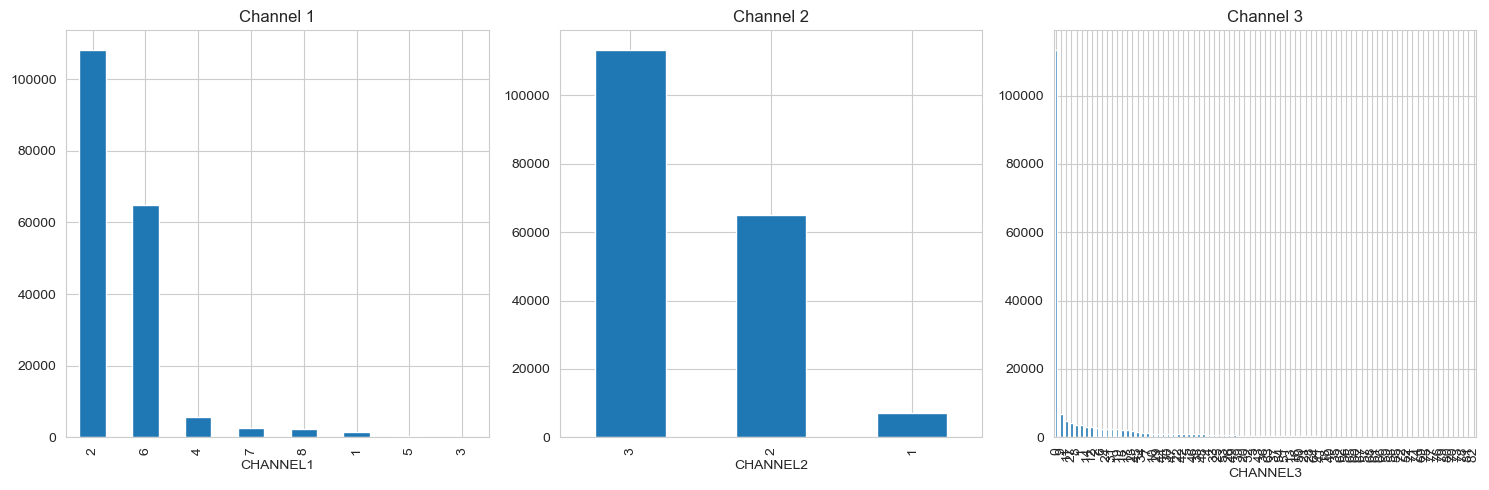

In [8]:
# inspecting the channel variables - CHANNEL1, CHANNEL2, CHANNEL3
# Plot Channel 1,2,3 out to see their values

# 1. Create a single figure with 3 subplots (axes)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 2. Assign each plot to a specific axis using the 'ax' parameter
df['CHANNEL1'].value_counts().plot(kind='bar', ax=axes[0], title='Channel 1')
df['CHANNEL2'].value_counts().plot(kind='bar', ax=axes[1], title='Channel 2')
df['CHANNEL3'].value_counts().plot(kind='bar', ax=axes[2], title='Channel 3')

# 3. Clean up the layout so labels don't overlap
plt.tight_layout()
plt.show()


### SEX, ENTRY AGE, PAYMENT METHOD
**(1) Sex:**

Intuitive definition. This dataset only categorizes individuals into male and female. Based on the first bar chart below, there is more male compared to female within this dataset, but not significantly different. 

**(2) Age:**

Intuitive definition, shown by the histogram in the second picture. Most individuals are centered at the adult age (20 - 50), followed by child/babies and then the least is the elderly (60-70). This makes sense because adult is mostly working, have family and property, which is likely to exposed themselves to higher and more variety of risk levels, causing them to buy more insurance policies. The least is the elderly, which also make sense because elderly are exposed to higher life-related risk due to health and sickness, hence less insurance firms are willing to offer policies to them. There is no datapoint beyond age 70, because according to the US insurance policy, the maximum application ages typicaly ranging from 75-80, so it is highly likely that no insurance firms are willing to take excessive risk to insure applicants beyond 70. 

**(3) Policy Year (Decimal):**

How long the policies have been in active (POLICY STATUS = INFORCE till the current date)

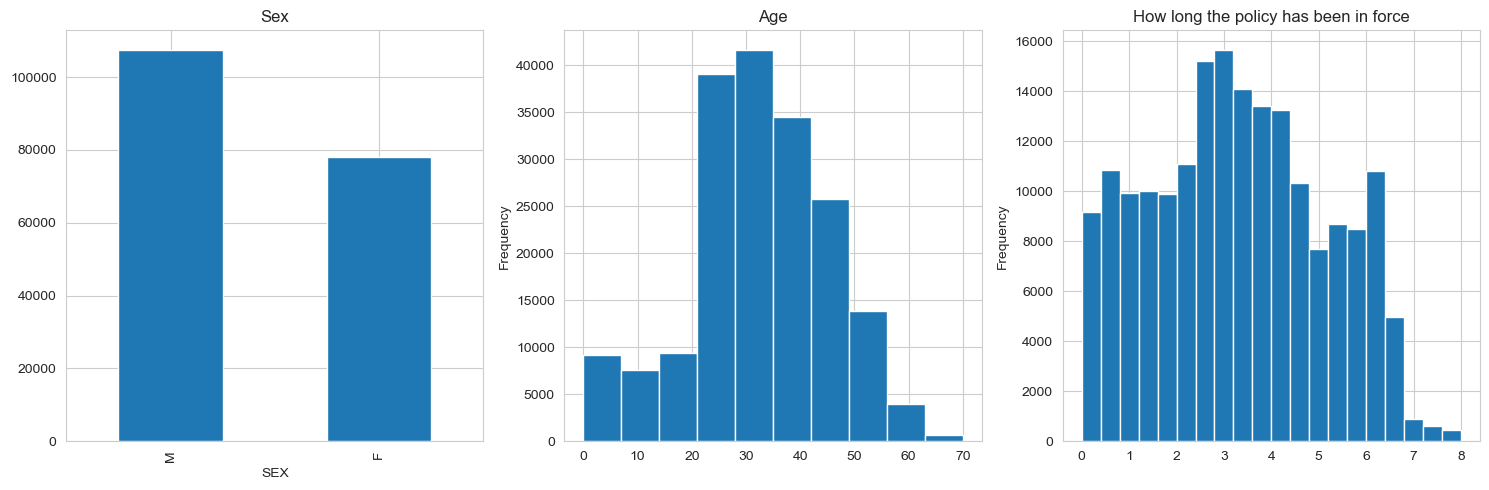

In [9]:
# inspecting the sex, age, payment method

# 1. Create a single figure with 3 subplots (axes)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 2. Assign each plot to a specific axis using the 'ax' parameter
df['SEX'].value_counts().plot(kind='bar', ax=axes[0], title='Sex')
df['ENTRY AGE'].plot(kind='hist', ax=axes[1], title='Age', bins=10)
df['POLICY YEAR (DECIMAL)'].plot(kind='hist', ax=axes[2], title='How long the policy has been in force', bins=20)

# 3. Clean up the layout so labels don't overlap
plt.tight_layout()
plt.show()


### POLICY STATUS, NON LAPSE GUARANTEED, SUBSTANDARD RISK

**(1) Policy Status:**

A. Inforce (Active)
- The policy is active and performing.
- Definition: The contract is in full effect, premiums are being paid (or the policy is paid-up), and the insurer is currently providing coverage.
- Modeling Role: In a Cox model, these are Censored observations because the "event" (lapse) has not happened yet as of the data snapshot.

B. Lapse (Passive Termination)
- The policy has terminated due to non-payment of premiums.
- Definition: The policyholder stopped paying, and the "grace period" (usually 30–61 days) has expired. The policy is canceled by the company, and typically, no death benefit or cash value is paid out.
- Behavioral Driver: Often linked to financial distress, forgetfulness, or "buyer's remorse" early in the policy life.

C. Surrender (Active Termination)
- The policyholder voluntarily terminates the contract to collect the Cash Value.
- Definition: This applies primarily to "Permanent" or "Whole Life" policies that build equity. The policyholder explicitly asks to cancel the policy in exchange for the "Surrender Value" (the accumulated savings minus fees).
- Behavioral Driver: Often a strategic financial decision—the policyholder needs cash for an emergency, is switching to a different investment, or no longer needs the coverage.

D. Expired (Natural Maturity)
- The policy reached its contractual end date.
- Definition: Most common in "Term Life" insurance. If you buy a 20-year term policy and stay alive for 20 years, the policy "expires." No benefit is paid, and the contract simply ends.
- Modeling Role: These are Censored. They didn't "quit"; they finished the marathon.

E. Death (Claim Paid)
- The insured event occurred, and the company paid the death benefit.
- Definition: The policy fulfilled its primary purpose. The contract is terminated because the claim was settled.
- Modeling Role: In survival analysis, this is a Competing Risk. A person cannot "Lapse" a policy if they are already deceased.

*In this experiment, our goal is to predict LAPSE vs NON-LAPSE (binary). Hence, we should cosider regrouping the variables into only two cateogories. LAPSE includes Lapse and Surrender, active and voluntary termination; NON-LAPSE includes INFORCE, EXPIRED, DEATH, passive and involuntary termination.*

**(2) Non-Lapse Guaranteed**

*A policy feature that ensures the death benefit remains in force even if the policy's cash value drops to zero, provided a specific premium requirement is met.*

A. NLG Suspend
- Meaning: The guarantee has been temporarily paused or "suspended." This typically happens when a policyholder misses a required premium payment or takes a policy loan that violates the guarantee's specific terms.
- Relationship to Lapse: This category shows a lapse rate of 1.0 (100%) in your chart. This indicates that once the safety net of the NLG is suspended, the policy is extremely vulnerable and, in your current data sample, almost always results in a lapse.


B. NLG Active
- Meaning: The guarantee is fully functional. The policyholder is meeting all premium requirements, and the insurance company is contractually obligated to keep the policy active regardless of cash value performance.
- Relationship to Lapse: Interestingly, this group has a high lapse rate (approx. 0.82). This suggests that even with a guarantee in place, a large portion of these policyholders are either choosing to walk away or failing to meet the basic premium payments required to keep the "Active" status.


C. NO NLG **(Majority of the policy)**
- Meaning: These are standard policies that do not have the Non-Lapse Guarantee feature. The policy stays active only as long as there is enough cash value to cover the monthly insurance costs.
- Relationship to Lapse: This group has a moderate lapse rate (approx. 0.63). They are actually lapsing less frequently than those with an "Active" NLG, which might imply these policies have more stable cash values or more traditional payment structures.


D. NLG Not Active
- Meaning: This likely refers to policies that could have had the guarantee, but it was never triggered or the policy did not qualify for it at the time of the data snapshot.
- Relationship to Lapse: This category has the lowest lapse rate (approx. 0.37). These policyholders appear to be the most stable group in your dataset, potentially because they are maintaining their policies through traditional cash value accumulation rather than relying on the guarantee feature.

**(3) Substandard Risk**

The extra mortality risk a policyholder carries compared to a "Standard" individual. The substandard risk must always be positive. Negative value is non-existent in standard substandard tables, as you cannot realistically model a risk lower than the "Preferred" floor already built into the product's pricing. If an individual is healthier than the average person, they aren't labeled as "Negative Substandard." Instead, they are placed into Preferred or Super Preferred categories.

1.25% of the policies have negative standard risk score, which is a small proportion. Since substandard risk must be >=0, we suspect negative values to be a typo, hence will drop these values.


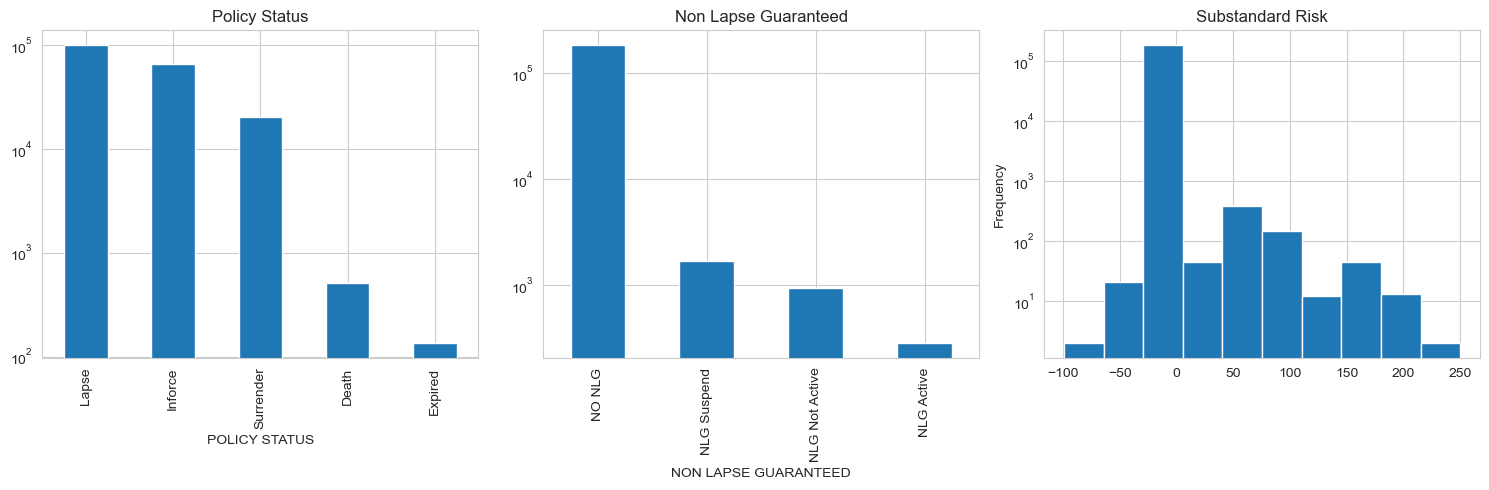

In [10]:
# Inspecting POLICY STATUS, NON LAPSE GUARANTEED, SUBSTANDARD RISK

# 1. Create a single figure with 3 subplots (axes)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 2. Assign each plot to a specific axis using the 'ax' parameter
df['POLICY STATUS'].value_counts().plot(kind='bar', ax=axes[0], title='Policy Status', logy=True)
# logy=TRUE is added to pull up the height of the low frequency x values to make it easier to see the distribution of the data, as there are some categories with very low frequency compared to others.

df['NON LAPSE GUARANTEED'].value_counts().plot(kind='bar', ax=axes[1], title='Non Lapse Guaranteed', logy=True)
df['SUBSTANDARD RISK'].plot(kind='hist', ax=axes[2], title='Substandard Risk', bins=10, logy=True)

# 3. Clean up the layout so labels don't overlap
plt.tight_layout()
plt.show()


In [11]:
# Check how many policies/proportion has negative standard risk score
df_negative = df[df['SUBSTANDARD RISK']<0]
df_negative.shape[0]/ df.shape[0]*100

# 1.25% of the policies have negative standard risk score, which is a small proportion. 
# Since substandard risk must be >=0, we suspect negative values to be a typo, hence will drop these values.

0.012394912696701876

### BENEFIT, INITIAL BENEFIT, FULL BENEFIT?
**(1) INITIAL BENEFIT**

This is the original face amount of the insurance policy at the time it was first issued. It represents the starting death benefit or coverage level agreed upon when the contract was signed.

**(2) BENEFIT**
This represents the current death benefit or total coverage amount as of the date of the data snapshot.
- Why it differs from Initial: In many life insurance products (like Universal Life or Whole Life), the benefit can grow over time due to paid-up additions, inflation adjustments, or accumulated dividends.
- Current Value: It is the actual amount that would be paid out if a claim were made today.

**(3) FULL BENEFIT?**
This is likely a binary indicator (Yes/No or 1/0) that identifies whether the policy has reached its maximum potential coverage or a specific milestone.

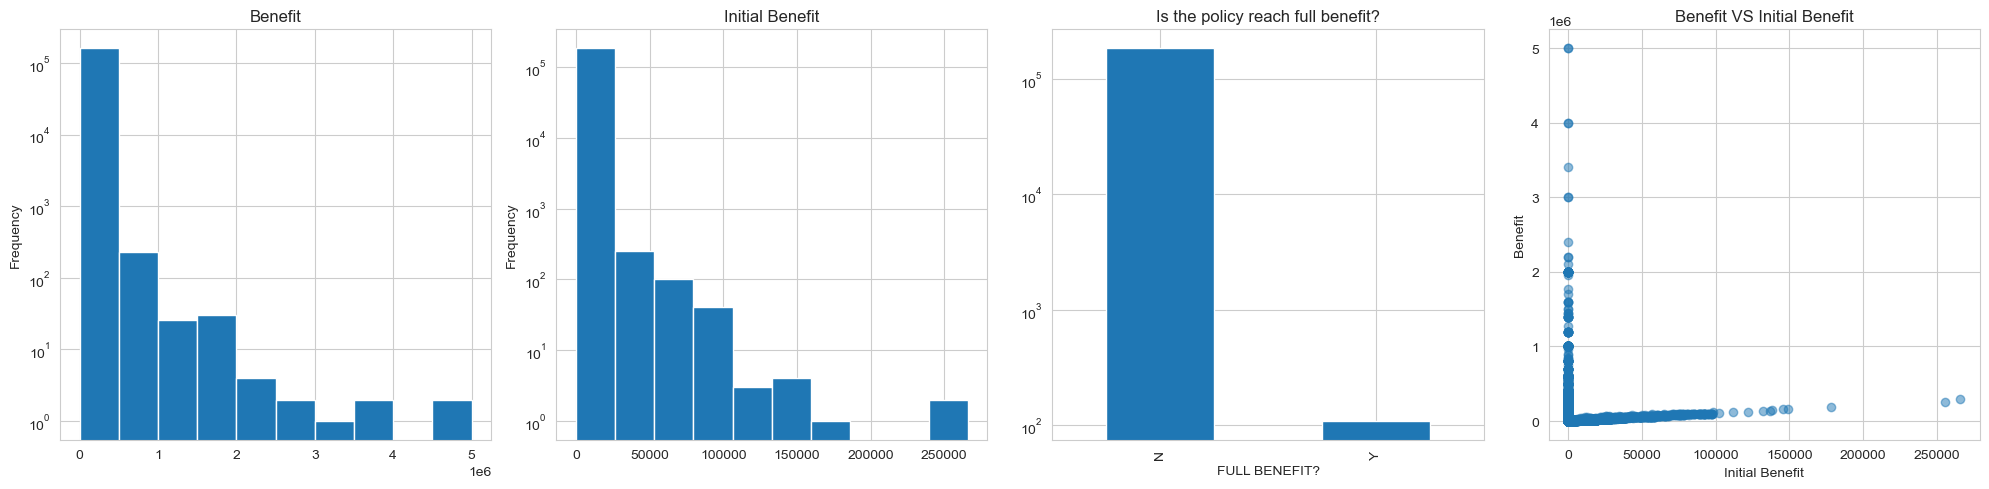

In [12]:
# inspecting the sex, age, payment method

# 1. Create a single figure with 4 subplots (axes)
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

# 2. Assign each plot to a specific axis using the 'ax' parameter
df['BENEFIT'].plot(kind='hist', ax=axes[0], title='Benefit', bins=10, logy=True)
df['INITIAL BENEFIT'].plot(kind='hist', ax=axes[1], title='Initial Benefit', bins=10, logy=True)
df['FULL BENEFIT?'].value_counts().plot(kind='bar', ax=axes[2], title='Is the policy reach full benefit?', logy=True)

# Use the axis object directly to plot the scatter
axes[3].scatter(df['INITIAL BENEFIT'], df['BENEFIT'], alpha=0.5)
axes[3].set_title('Benefit VS Initial Benefit')
axes[3].set_xlabel('Initial Benefit')
axes[3].set_ylabel('Benefit')

# 3. Clean up the layout and show once
plt.tight_layout()
plt.show()


In [13]:
df['FULL BENEFIT?'].value_counts()
# 90% of the policies have reached full benefit, which is expected as the dataset is from a insurance company and they would want to retain customers until they reach full benefit.

FULL BENEFIT?
N    185451
Y       109
Name: count, dtype: int64

### PREMIUM, NUMBER OF ADVANCE PREMIUM, PAYMENT MODE
**(1) PREMIUM**

This is the specific dollar amount the policyholder is required to pay to keep the insurance policy active. It is based on the risk level (like the "Substandard Risk" we discussed), the "Benefit" amount, and the age of the individual.

**(2) NUMBER OF ADVANCE PREMIUM**

This indicates how many future premium payments the policyholder has paid in advance of their actual due dates. Some policyholders prefer to pay for several months or years at once to ensure the policy doesn't lapse if they forget a payment.

**(3) PAYMENT MODE**

This describes the frequency at which the premium payments are made. Typically, policies paid "Annually" have lower lapse rates than those paid "Monthly," as there are fewer opportunities for a payment to be missed.

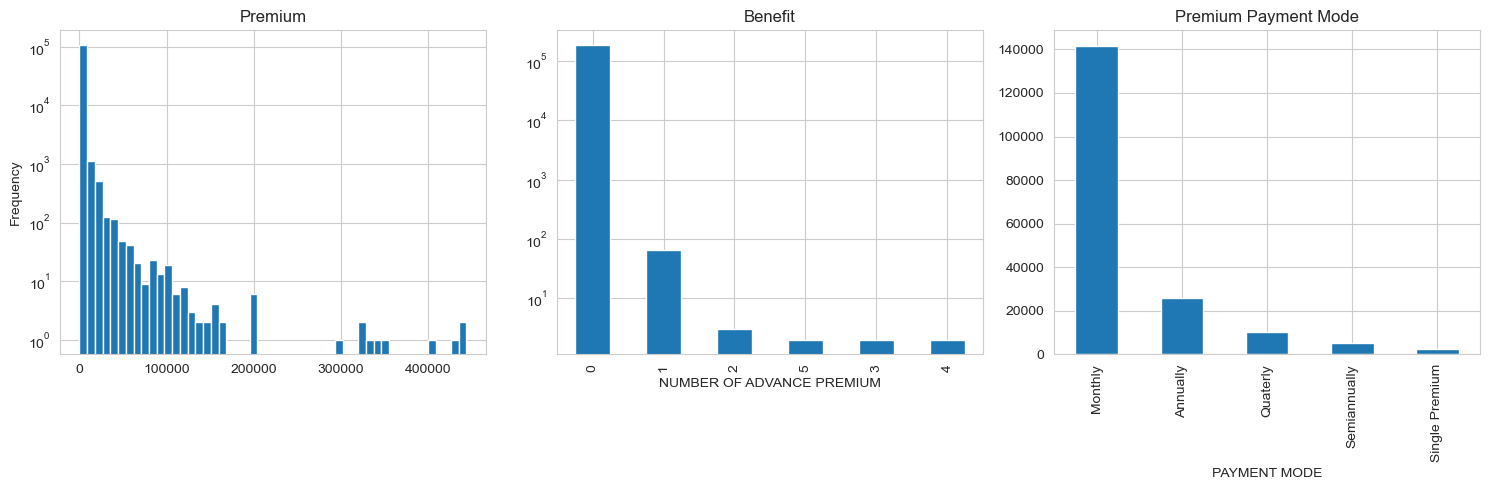

In [ ]:
# inspecting the sex, age, payment method

# 1. Create a single figure with 3 subplots (axes)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 2. Assign each plot to a specific axis using the 'ax' parameter
df['PREMIUM'].plot(kind='hist', ax=axes[0], title='Premium', bins=50, logy=True)
df['NUMBER OF ADVANCE PREMIUM'].value_counts().plot(kind='bar', ax=axes[1], title='Number of Advanced Premium', logy=True)
df['PAYMENT MODE'].value_counts().plot(kind='bar', ax=axes[2], title='Premium Payment Mode')

# 3. Clean up the layout so labels don't overlap
plt.tight_layout()
plt.show()

### POLICY TYPE variables inspection
In the insurance context, insurance products are rarely just one thing; they are usually a base plan with various riders or specific **internal classifications**.

(1) Policy Type 1 (Product Class): This is likely the "Big Picture" product line.
Example: 1 = Term Life, 2 = Whole Life, 3 = Universal Life.

(2) Policy Type 2 (Sub-Product/Plan): Within a class, there are different variations.
Example: If Type 1 is "Term Life," Type 2 might be 1 = 10-year term or 2 = 20-year term.

(3) Policy Type 3 (Risk or Premium Class): This often correlates with the "Non-Lapse Guaranteed" (NLG) column or the "Benefit" amount. It might represent the specific underwriting tier or the specific dividend structure of the policy.

While this is the possible explanation and interpretation of each channel, the dataset lack clear definition in terms of the information these columns provided. This might be useful in producing an interpretable model, but we should not leave them out since they might carry information that contributes to prediction accuracy. 

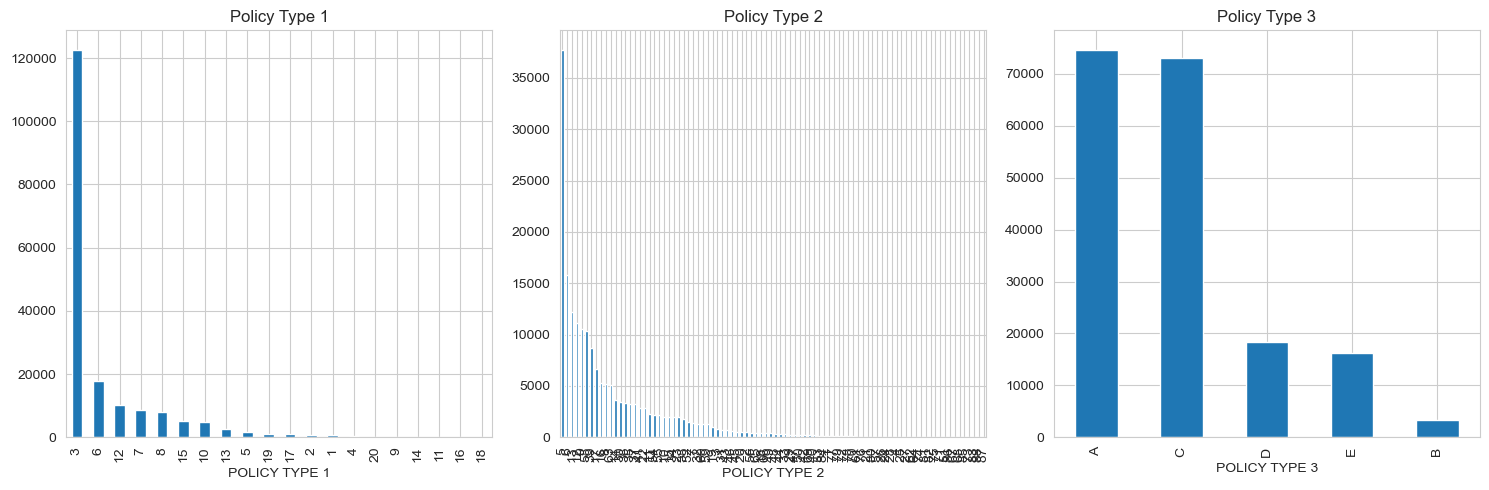

In [15]:
# inspecting the policy type variables - POLICY TYPE 1, POLICY TYPE 2, POLICY TYPE 3
# 1. Create a single figure with 3 subplots (axes)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 2. Assign each plot to a specific axis using the 'ax' parameter
df['POLICY TYPE 1'].value_counts().plot(kind='bar', ax=axes[0], title='Policy Type 1')
df['POLICY TYPE 2'].value_counts().plot(kind='bar', ax=axes[1], title='Policy Type 2')
df['POLICY TYPE 3'].value_counts().plot(kind='bar', ax=axes[2], title='Policy Type 3')

# 3. Clean up the layout so labels don't overlap
plt.tight_layout()
plt.show()

## NA Values Checking and Imputation
In computing the NA values, we will go for 3 different methods:
1. Median imputation
2. KNN imputation
3. Quantile regression

We will first split the data into training and validation dataset using a 70-30 splits. We will then use test MSE to evaluate the the methods, and will go for the approaches that produces prediction with the lowest test MSE.

In [6]:
# import necessary libraries
from sklearn.model_selection import train_test_split
from sklearn.impute import KNNImputer
from sklearn.metrics import mean_absolute_error
import statsmodels.formula.api as smf
from sklearn.preprocessing import StandardScaler


In [7]:
# inspect the data to see the positions of the NA values within each column
df.isna().sum()
# benefit and premium have the most number of NA values

CHANNEL1                         0
CHANNEL2                         0
CHANNEL3                         0
ENTRY AGE                        0
SEX                              0
POLICY TYPE 1                    0
POLICY TYPE 2                    0
POLICY TYPE 3                    0
PAYMENT MODE                     0
POLICY STATUS                    0
BENEFIT                      23664
NON LAPSE GUARANTEED             0
SUBSTANDARD RISK                 0
NUMBER OF ADVANCE PREMIUM        0
INITIAL BENEFIT                  0
Full Benefit?                    0
Policy Year (Decimal)            0
Policy Year                      0
Premium                      77127
Issue Date                       0
dtype: int64

In [10]:
# set up data split using the 70/30 rule
# filter for rows where both columns are present to create a "Ground Truth" set, wihtout NA values
complete_df = df.dropna(subset=['PREMIUM', 'BENEFIT']).copy()

train_df, val_df = train_test_split(complete_df, test_size=0.3, random_state=42)

# Create a 'test' set with artificial NAs to measure accuracy
val_with_holes = val_df.copy()
# Hide 10% of Premiums and 10% of Benefits randomly
val_with_holes.loc[val_with_holes.sample(frac=0.1).index, 'PREMIUM'] = np.nan
val_with_holes.loc[val_with_holes.sample(frac=0.1).index, 'BENEFIT'] = np.nan

# checking the val_with_holes data frame
# make sure there is random NA values in the PREMIUM and BENEFIT columns
val_with_holes.head(20)
# yes, verified

,CHANNEL1,CHANNEL2,CHANNEL3,ENTRY AGE,SEX,POLICY TYPE 1,POLICY TYPE 2,POLICY TYPE 3,PAYMENT MODE,POLICY STATUS,BENEFIT,NON LAPSE GUARANTEED,SUBSTANDARD RISK,NUMBER OF ADVANCE PREMIUM,INITIAL BENEFIT,FULL BENEFIT?,POLICY YEAR (DECIMAL),POLICY YEAR,PREMIUM,ISSUE DATE
135910,6,2,8,27,F,7,39,A,Monthly,Surrender,80000.0,NO NLG,0.0,0,0.0,N,3.750000,4,303.0,15-Nov
139304,6,2,14,37,M,7,39,A,Monthly,Lapse,22000.0,NO NLG,0.0,0,0.0,N,3.666667,4,150.0,15-Dec
113573,4,1,4,30,F,3,5,A,Monthly,Lapse,86000.0,NO NLG,0.0,0,0.0,N,4.166667,5,2640.0,15-Jun
89630,2,3,0,33,M,3,5,A,Monthly,Lapse,20000.0,NO NLG,0.0,0,0.0,N,5.416667,6,1200.0,14-Mar
98392,2,3,0,43,F,17,65,A,Monthly,Lapse,50000.0,NO NLG,0.0,0,0.0,N,0.916667,1,1308.0,18-Sep
98890,2,3,0,32,F,3,5,A,Annually,Surrender,NaN,NO NLG,0.0,0,0.0,N,7.666667,8,400.0,11-Dec
174965,6,2,42,31,M,6,38,E,Monthly,Lapse,5000.0,NO NLG,0.0,0,0.0,N,3.750000,4,55.0,15-Nov
79009,2,3,0,36,F,3,5,A,Monthly,Lapse,20000.0,NO NLG,0.0,0,0.0,N,5.166667,6,1200.0,14-Jun
34037,2,3,0,31,F,3,5,A,Semiannually,Lapse,35000.0,NO NLG,0.0,0,0.0,N,6.250000,7,500.0,13-May
62835,2,3,0,38,F,3,5,A,Monthly,Lapse,NaN,NO NLG,0.0,0,0.0,N,4.750000,5,1200.0,14-Nov


In [11]:
# we need to use test MSE to decide which imputation method to use, we set up here
# compute MSE to compare between two methods
from sklearn.metrics import mean_squared_error

# identify where we "punched holes" (the indices of the missing values)
premium_mask = val_with_holes['PREMIUM'].isna()
benefit_mask = val_with_holes['BENEFIT'].isna()

# extract Ground Truth (Actual values we hid)
true_premium = val_df.loc[premium_mask, 'PREMIUM']
true_benefit = val_df.loc[benefit_mask, 'BENEFIT']

In [12]:
# Ensure you have your 'complete_df' ready before this block
complete_df = df.dropna(subset=['PREMIUM', 'BENEFIT']).copy()

n_iterations = 30 # As seen in your sketch
k_list = [3, 4, 5, 6, 7, 8, 9, 10, 15, 20, 23, 25, 30, 35, 40, 45, 50]
mse_p_results = []
mse_b_results = []

for i in range(n_iterations):
    # 1. Bootstrap Resampling, make sure each index is reset and unique
    boot_df = complete_df.sample(frac=1.0, replace=True).reset_index(drop=True)
    
    # 2. Split (70/30)
    train_df = boot_df.sample(frac=0.7)
    val_df = boot_df.drop(train_df.index)
    
    # Create artificial holes (10% each)
    val_with_holes = val_df.copy()
    # Note: using indices to ensure we can track back correctly
    p_idx = val_with_holes.sample(frac=0.1).index
    b_idx = val_with_holes.sample(frac=0.1).index
    
    val_with_holes.loc[p_idx, 'PREMIUM'] = np.nan
    val_with_holes.loc[b_idx, 'BENEFIT'] = np.nan

    premium_mask = val_with_holes['PREMIUM'].isna()
    benefit_mask = val_with_holes['BENEFIT'].isna()

    true_premium = val_df.loc[premium_mask, 'PREMIUM']
    true_benefit = val_df.loc[benefit_mask, 'BENEFIT']
    
    # --- Model 2: KNN with internal Best-K Search ---
    scaler = StandardScaler()
    train_sc = scaler.fit_transform(train_df[['PREMIUM', 'BENEFIT']])
    val_sc = scaler.transform(val_with_holes[['PREMIUM', 'BENEFIT']])

    best_mse_p, best_mse_b = None, None
    best_avg_mse = float('inf')
    winning_k = None

    # Dicts to hold MSEs for this specific iteration across all k
    iter_p = {'iteration': i}
    iter_b = {'iteration': i}

    for k in k_list:
        knn_imputer = KNNImputer(n_neighbors=k)
        # Fit on train, transform validation
        val_imputed_sc = knn_imputer.fit(train_sc).transform(val_sc)
        
        # Inverse transform to get original scale
        val_imputed_raw = pd.DataFrame(
            scaler.inverse_transform(val_imputed_sc), 
            columns=['PREMIUM', 'BENEFIT'], 
            index=val_with_holes.index
        )
    
        # Calculate MSEs for this K
        mse_p = mean_squared_error(true_premium, val_imputed_raw.loc[premium_mask, 'PREMIUM'])
        mse_b = mean_squared_error(true_benefit, val_imputed_raw.loc[benefit_mask, 'BENEFIT'])
        
        iter_p[k] = mse_p
        iter_b[k] = mse_b

    mse_p_results.append(iter_p)
    mse_b_results.append(iter_b)

# --- Generate Tables ---
table_mse_p = pd.DataFrame(mse_p_results).set_index('iteration')
table_mse_b = pd.DataFrame(mse_b_results).set_index('iteration')

# Adding the 'Best K' column as per your sketch
table_mse_p['Best K'] = table_mse_p.idxmin(axis=1)
table_mse_b['Best K'] = table_mse_b.idxmin(axis=1)

KeyboardInterrupt: 

In [32]:
table_mse_p.head(5)
table_mse_p['Best K'].value_counts()

Best K
3     5
15    5
4     4
50    3
7     2
8     2
20    2
9     2
25    1
5     1
45    1
10    1
40    1
Name: count, dtype: int64

In [33]:
table_mse_b['Best K'].value_counts()

Best K
30    5
40    4
15    3
50    3
3     3
4     3
10    2
20    2
9     2
6     1
7     1
45    1
Name: count, dtype: int64

Based on the imputation above, we can identify the best K for each premium and benefit, so that we can start doing data imputation and comparing them to other methods. 

(1) Best K for premium = 3, 15 (we will try with these two different K to compare the MSE at the end)

(2) Best K for benefit = 30

In [13]:
# from now on, we have both training and "artifically validation" datasets, we will start with the three methods
# Model 1: benchmark model - mean imputation

# compute the median for  Premium and Benefit to fill in the missing values - check the MSE
# Calculate the Median from the TRAINING set only
# (We use training data to avoid "data leakage")
train_median_premium = train_df['PREMIUM'].median()
train_median_benefit = train_df['BENEFIT'].median()

# create "Predictions" using the Median
# for every 'hole' we made in the validation set, we just guess the median
median_pred_premium = np.full(shape=true_premium.shape, fill_value=train_median_premium)
median_pred_benefit = np.full(shape=true_benefit.shape, fill_value=train_median_benefit)

# calculate MSE for Median
mse_median_p = mean_squared_error(true_premium, median_pred_premium)
mse_median_b = mean_squared_error(true_benefit, median_pred_benefit)

print(f'MSE for Median Imputation - PREMIUM: {mse_median_p:.2f}, BENEFIT: {mse_median_b:.2f}')

MSE for Median Imputation - PREMIUM: 13630353.44, BENEFIT: 6754695669.97


In [18]:
# Model 2: KNN imputation
# We scale the data first because KNN is distance-based.
scaler = StandardScaler()

# Important: We fit the scaler only on the training data to avoid data leakage, 
# then transform both train and validation sets
train_scaled = scaler.fit_transform(train_df[['PREMIUM', 'BENEFIT']])
val_scaled = scaler.transform(val_with_holes[['PREMIUM', 'BENEFIT']])

# KNN Imputer (Uses mean of neighbors by default)
# Imputation for premium
# K=3
knn_imputer = KNNImputer(n_neighbors=3)
val_imputed_knn = knn_imputer.fit_transform(val_scaled)
    
#inverse transform back to original scale
val_imputed_knn = pd.DataFrame(scaler.inverse_transform(val_imputed_knn), 
                                columns=['PREMIUM','BENEFIT'], 
                                index=val_with_holes.index)
    
# extract the KNN predictions for the "holes" we punched
knn_pred_premium = val_imputed_knn.loc[premium_mask, 'PREMIUM']
mse_knn_p = mean_squared_error(true_premium, knn_pred_premium)
print(f'K={3}: MSE for PREMIUM={mse_knn_p:.2f}')

K=3: MSE for PREMIUM=12999899.84


In [19]:
# Model 2: KNN imputation
# We scale the data first because KNN is distance-based.
scaler = StandardScaler()

# Important: We fit the scaler only on the training data to avoid data leakage, 
# then transform both train and validation sets
train_scaled = scaler.fit_transform(train_df[['PREMIUM', 'BENEFIT']])
val_scaled = scaler.transform(val_with_holes[['PREMIUM', 'BENEFIT']])

# KNN Imputer (Uses mean of neighbors by default)
# Imputation for premium
# K=15
knn_imputer = KNNImputer(n_neighbors=15)
val_imputed_knn = knn_imputer.fit_transform(val_scaled)
    
#inverse transform back to original scale
val_imputed_knn = pd.DataFrame(scaler.inverse_transform(val_imputed_knn), 
                                columns=['PREMIUM','BENEFIT'], 
                                index=val_with_holes.index)
    
# extract the KNN predictions for the "holes" we punched
knn_pred_premium = val_imputed_knn.loc[premium_mask, 'PREMIUM']
mse_knn_p = mean_squared_error(true_premium, knn_pred_premium)
print(f'K={15}: MSE for PREMIUM={mse_knn_p:.2f}')

K=15: MSE for PREMIUM=9340850.82


Based on the result above, K=15 yields a lower MSE for Premium, compared to K=3. We will use K=15 to impute NAs for the Premium Variables.

In [24]:
# Model 2: KNN imputation
# We scale the data first because KNN is distance-based.
scaler = StandardScaler()

# Important: We fit the scaler only on the training data to avoid data leakage, 
# then transform both train and validation sets
train_scaled = scaler.fit_transform(train_df[['PREMIUM', 'BENEFIT']])
val_scaled = scaler.transform(val_with_holes[['PREMIUM', 'BENEFIT']])

# KNN Imputer (Uses mean of neighbors by default)
# Imputation for benefit
# K=30
knn_imputer = KNNImputer(n_neighbors=30)
val_imputed_knn = knn_imputer.fit_transform(val_scaled)
    
#inverse transform back to original scale
val_imputed_knn = pd.DataFrame(scaler.inverse_transform(val_imputed_knn), 
                                columns=['PREMIUM','BENEFIT'], 
                                index=val_with_holes.index)
    
# extract the KNN predictions for the "holes" we punched
knn_pred_benefit = val_imputed_knn.loc[benefit_mask, 'BENEFIT']
mse_knn_b = mean_squared_error(true_benefit, knn_pred_benefit)
print(f'K={30}: MSE for BENEFIT={mse_knn_b:.2f}')

K=30: MSE for BENEFIT=5657737305.84


In [23]:
from sklearn.preprocessing import StandardScaler
import statsmodels.formula.api as smf

# 1. Scale the data first
# We use the same scaler logic as before to prevent leakage
scaler_qr = StandardScaler()
train_scaled_df = pd.DataFrame(
    scaler_qr.fit_transform(train_df[['PREMIUM', 'BENEFIT']]),
    columns=['PREMIUM', 'BENEFIT']
)

# 2. Fit the models on scaled data with higher iteration limits
# Increasing max_iter helps resolve the 'IterationLimitWarning'
mod_p = smf.quantreg('PREMIUM ~ BENEFIT', train_scaled_df).fit(q=0.5, max_iter=5000)
mod_b = smf.quantreg('BENEFIT ~ PREMIUM', train_scaled_df).fit(q=0.5, max_iter=5000)

# 3. Prepare the validation data (Scale it using the training scaler)
val_scaled_qr = pd.DataFrame(
    scaler_qr.transform(val_with_holes[['PREMIUM', 'BENEFIT']]),
    columns=['PREMIUM', 'BENEFIT'],
    index=val_with_holes.index
)

# 4. Apply predictions in the scaled space
val_scaled_qr['PREMIUM'] = val_scaled_qr['PREMIUM'].fillna(mod_p.predict(val_scaled_qr))
val_scaled_qr['BENEFIT'] = val_scaled_qr['BENEFIT'].fillna(mod_b.predict(val_scaled_qr))

# 5. Inverse transform back to original scale to calculate true MSE
val_final_qr = pd.DataFrame(
    scaler_qr.inverse_transform(val_scaled_qr),
    columns=['PREMIUM', 'BENEFIT'],
    index=val_with_holes.index
)

# 6. Extract and calculate MSE (Filtering NaNs as you did before)
qr_pred_premium = val_final_qr.loc[premium_mask, 'PREMIUM']
qr_pred_benefit = val_final_qr.loc[benefit_mask, 'BENEFIT']

mask_p = qr_pred_premium.notna()
mse_qr_p = mean_squared_error(true_premium[mask_p], qr_pred_premium[mask_p])

mask_b = qr_pred_benefit.notna()
mse_qr_b = mean_squared_error(true_benefit[mask_b], qr_pred_benefit[mask_b])

print(f'MSE (Scaled) - PREMIUM: {mse_qr_p:.2f}, BENEFIT: {mse_qr_b:.2f}')

MSE (Scaled) - PREMIUM: 8524639.07, BENEFIT: 4808801494.70


In [25]:
# adjustment for KNN computation
# based on the result above, K=5 produces the lowest test MSE for PREMIUM, whereas K=15 produces the lowest test MSE for BENEFIT.

# KNN computation for PREMIUM with K=15
knn_imputer_p = KNNImputer(n_neighbors=15)
val_imputed_knn_p = knn_imputer_p.fit_transform(val_scaled)

# inverse transform back to original scale
val_imputed_knn_p = pd.DataFrame(scaler.inverse_transform(val_imputed_knn_p),
                                 columns=['PREMIUM','BENEFIT'],
                                 index=val_with_holes.index)

# KNN computation for PREMIUM with K=30
knn_imputer_b = KNNImputer(n_neighbors=30)
val_imputed_knn_b = knn_imputer_b.fit_transform(val_scaled)

# inverse transform back to original scale
val_imputed_knn_b = pd.DataFrame(scaler.inverse_transform(val_imputed_knn_b),
                                 columns=['PREMIUM','BENEFIT'],
                                 index=val_with_holes.index)

# extract the KNN predictions
 # extract the KNN predictions for the "holes" we punched
knn_pred_premium = val_imputed_knn_p.loc[premium_mask, 'PREMIUM']
knn_pred_benefit = val_imputed_knn_b.loc[benefit_mask, 'BENEFIT']

mse_knn_p = mean_squared_error(true_premium, knn_pred_premium) #k=15
mse_knn_b = mean_squared_error(true_benefit, knn_pred_benefit) #k=30

In [26]:
# Compare everything (using MSE for easier reading in dollar amounts)
print("--- ACCURACY COMPARISON (MSE) ---")

print("--- MSE Comparison: PREMIUM ---")
print(f"Median Baseline MSE:   {mse_median_p:,.2f}")
print(f"KNN Imputation MSE: {mse_knn_p:,.2f}")
print(f"Quantile Reg MSE:   {mse_qr_p:,.2f}")

print("\n--- MSE Comparison: BENEFIT ---")
print(f"Median Baseline MSE:   {mse_median_b:,.2f}")
print(f"KNN Imputation MSE: {mse_knn_b:,.2f}")
print(f"Quantile Reg MSE:   {mse_qr_b:,.2f}")

--- ACCURACY COMPARISON (MSE) ---
--- MSE Comparison: PREMIUM ---
Median Baseline MSE:   13,630,353.44
KNN Imputation MSE: 9,340,850.82
Quantile Reg MSE:   8,524,639.07

--- MSE Comparison: BENEFIT ---
Median Baseline MSE:   6,754,695,669.97
KNN Imputation MSE: 5,657,737,305.84
Quantile Reg MSE:   4,808,801,494.70


In [27]:
# Based on the result above, we will use quantile regression to impute NAs for both Premium and Benefit
# We only use the columns involved in the calculation
cols_to_fix = ['PREMIUM', 'BENEFIT']
data_for_imputation = df[cols_to_fix].copy()

# Fit quantile regression models on the complete cases (non-NA) to predict missing values
mod_p = smf.quantreg('PREMIUM ~ BENEFIT', df).fit(q=0.5, max_iter=5000)
mod_b = smf.quantreg('BENEFIT ~ PREMIUM', df).fit(q=0.5, max_iter=5000) 

# Fill in NAs values
df['PREMIUM'] = df['PREMIUM'].fillna(mod_p.predict(df))
df['BENEFIT'] = df['BENEFIT'].fillna(mod_b.predict(df))

# Final verification
print(f"Missing values in Premium: {df['PREMIUM'].isna().sum()}")
print(f"Missing values in Benefit: {df['BENEFIT'].isna().sum()}")

Missing values in Premium: 4315
Missing values in Benefit: 4315


In [29]:
# Create a mask for rows where BOTH Premium and Benefit are NaN
both_missing = df['PREMIUM'].isna() & df['BENEFIT'].isna()
df[both_missing].head()

,CHANNEL1,CHANNEL2,CHANNEL3,ENTRY AGE,SEX,POLICY TYPE 1,POLICY TYPE 2,POLICY TYPE 3,PAYMENT MODE,POLICY STATUS,BENEFIT,NON LAPSE GUARANTEED,SUBSTANDARD RISK,NUMBER OF ADVANCE PREMIUM,INITIAL BENEFIT,FULL BENEFIT?,POLICY YEAR (DECIMAL),POLICY YEAR,PREMIUM,ISSUE DATE
1471,2,3,0,53,M,3,7,B,Annually,Lapse,NaN,NLG Not Active,0.0,0,0.0,N,7.583333,8,NaN,12-Jan
1472,2,3,0,53,M,3,7,B,Annually,Lapse,NaN,NLG Not Active,0.0,0,0.0,N,7.583333,8,NaN,12-Jan
1806,2,3,0,38,M,3,7,B,Monthly,Inforce,NaN,NLG Not Active,0.0,0,0.0,N,6.250000,7,NaN,13-May
1832,2,3,0,1,F,3,7,B,Semiannually,Surrender,NaN,NLG Not Active,0.0,0,0.0,N,6.250000,7,NaN,13-May
1835,2,3,0,17,F,3,6,D,Annually,Inforce,NaN,NLG Not Active,0.0,0,0.0,N,6.250000,7,NaN,13-May


In [30]:
df[both_missing].shape[0]

4315

After fitting in the NAs values imputed by quantile regression, there are still 4315 observations with NAs values in Premium and Benefit, proven by the examination above. This is because quantile regression relies on fitting Premium onto Benefit or the other way round to predict the missing NAs. Since both variables are NAs for the 4315 rows, no imputation can be done. 

We can instead fit them with the global median of both Benefit and Premium.

In [31]:
# Fitting 4315 rows that have both Premium and Benefit missing with median imputation, as quantile regression cannot be applied to these rows due to the absence of any data points to predict from.
if df['PREMIUM'].isna().any():
    df['PREMIUM'] = df['PREMIUM'].fillna(df['PREMIUM'].median())

if df['BENEFIT'].isna().any():
    df['BENEFIT'] = df['BENEFIT'].fillna(df['BENEFIT'].median())

# Final verification
print(f"Missing values in Premium: {df['PREMIUM'].isna().sum()}")
print(f"Missing values in Benefit: {df['BENEFIT'].isna().sum()}")

Missing values in Premium: 0
Missing values in Benefit: 0


In [32]:
# Sanity Check on any missing values
df.isna().sum()

CHANNEL1                     0
CHANNEL2                     0
CHANNEL3                     0
ENTRY AGE                    0
SEX                          0
POLICY TYPE 1                0
POLICY TYPE 2                0
POLICY TYPE 3                0
PAYMENT MODE                 0
POLICY STATUS                0
BENEFIT                      0
NON LAPSE GUARANTEED         0
SUBSTANDARD RISK             0
NUMBER OF ADVANCE PREMIUM    0
INITIAL BENEFIT              0
FULL BENEFIT?                0
POLICY YEAR (DECIMAL)        0
POLICY YEAR                  0
PREMIUM                      0
ISSUE DATE                   0
dtype: int64

## Formating response variables

This project is a classification problem, where we aim to utilize different machine learning methods to predict the accuracy of our classification models. To simplify our problem, we will categorize our response variable into only binary (i.e. Lapse VS Non-Lapse).

### Method 1: The Adversarial Classifier Test
This is the "gold standard" for feature engineering. We try to train a model specifically to distinguish between Lapse and Surrender. If the model fails (AUC $\approx$ 0.50), they are effectively the same to your classifier.

In [34]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import LabelEncoder

# 1. Filter only for the two classes we want to compare
adv_df = df[df['POLICY STATUS'].isin(['Lapse', 'Surrender'])].copy()
adv_df['IS_LAPSE'] = (adv_df['POLICY STATUS'] == 'Lapse').astype(int)

# 2. Prepare features (Drop the target and any non-predictive IDs)
# Make sure to handle categoricals if you have them (e.g., via dummy variables)
X = pd.get_dummies(adv_df.drop(columns=['POLICY STATUS', 'IS_LAPSE']), drop_first=True)
y = adv_df['IS_LAPSE']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 3. Train a Random Forest to see if it can "tell the difference"
clf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
clf.fit(X_train, y_train)

# 4. Check AUC
probs = clf.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, probs)

print(f"Adversarial AUC: {auc:.3f}")
print("Interpretation: AUC near 0.50 means the classes are indistinguishable.")
print("If AUC > 0.70, they are distinct and should probably stay separate.")

Adversarial AUC: 0.681
Interpretation: AUC near 0.50 means the classes are indistinguishable.
If AUC > 0.70, they are distinct and should probably stay separate.


### Method 2: Visualizing Overlap (FAMD)
FAMD = Factor Analysis of Mixed Data

The method reduces our high-dimensional data, consisting of a mix of categorical/string variables and numerical variables, into two componenets to see if the two classes naturally cluster together or separate.

In [65]:
pip install prince

Note: you may need to restart the kernel to use updated packages.


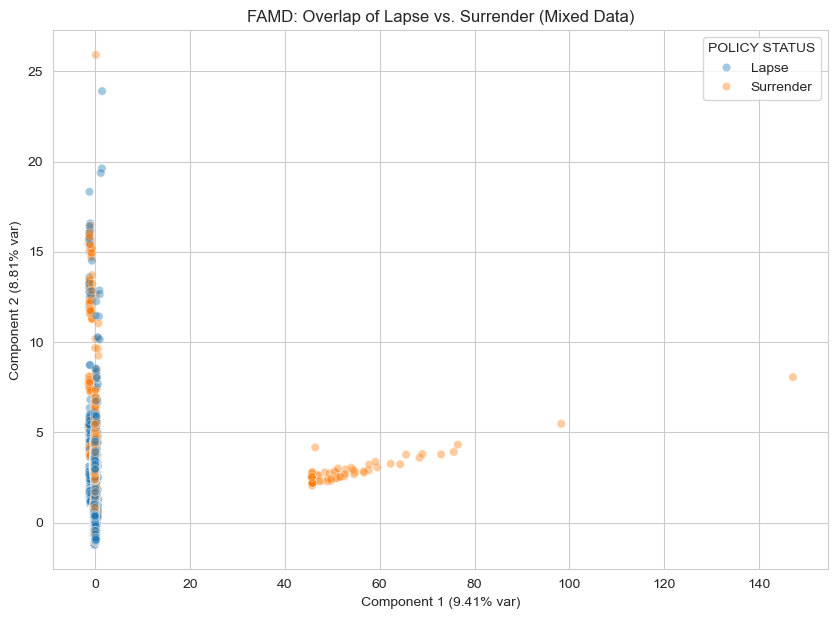

In [66]:
# !pip install prince
import prince
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Prepare your comparison dataset
# Subset for just the two statuses you want to test
famd_df = df[df['POLICY STATUS'].isin(['Lapse', 'Surrender'])].copy()

# 2. Identify and Clean your columns
# Prince automatically detects types, but it's safer to be explicit
categorical_cols = ['SEX', 'PAYMENT MODE', 'NON LAPSE GUARANTEED', 'FULL BENEFIT?'] 
numeric_cols = ['ENTRY AGE', 'BENEFIT','SUBSTANDARD RISK','NUMBER OF ADVANCE PREMIUM',
'INITIAL BENEFIT', 'POLICY YEAR (DECIMAL)', 'PREMIUM']

# Ensure types are correct for the engine
for col in categorical_cols:
    famd_df[col] = famd_df[col].astype('category')
for col in numeric_cols:
    famd_df[col] = famd_df[col].astype(float)

# 3. Fit the FAMD model
famd = prince.FAMD(
    n_components=2,
    n_iter=3,
    copy=True,
    check_input=True,
    engine='sklearn',
    random_state=42
)
famd = famd.fit(famd_df[categorical_cols + numeric_cols])

# 4. Get the results (coordinates in 2D space)
row_coords = famd.row_coordinates(famd_df)

# 5. Visualize
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x=row_coords[0], 
    y=row_coords[1], 
    hue=famd_df['POLICY STATUS'],
    alpha=0.4
)
plt.title('FAMD: Overlap of Lapse vs. Surrender (Mixed Data)')
plt.xlabel(f"Component 1 ({famd.eigenvalues_summary.iloc[0, 1]} var)")
plt.ylabel(f"Component 2 ({famd.eigenvalues_summary.iloc[1, 1]} var)")
plt.show()

In [67]:
# This will show you which features are pushing those dots to the right
contributions = famd.column_contributions_
print(contributions.sort_values(by=0, ascending=False).head(5))

component                     0         1
variable                                 
PAYMENT MODE           0.410573  0.318973
INITIAL BENEFIT        0.161381  0.000352
NON LAPSE GUARANTEED   0.003909  0.133286
POLICY YEAR (DECIMAL)  0.003860  0.013800
ENTRY AGE              0.002019  0.002589


Our FAMD analysis shows that the 'feature space' for Lapses and Surrenders is almost entirely overlapping. While a small subset of Surrenders shows unique behavior (the horizontal tail), the vast majority of policyholders who exit the system look identical regardless of the label. Therefore, merging them into a single 'Voluntary Exit' category is statistically justified.

Based on the result above, we can see that PAYMENT MODE is the primary driver for both component 0 and component 1, shifting the cluster to the right for the Surrender categories. This can be explained as those who surrender likely to stick to one payment mode compared to those who lapse. In particular, those who pay annually in advanced might opt for surrender, so they can get whatever is available in their accounts back for their benefits. 

In [68]:
# 1. Identify the 'Tail' vs the 'Pillar'
# Based on your plot, the 'Tail' starts where Component 0 > 20
row_coords['Component_0'] = row_coords.iloc[:, 0]
tail_threshold = 20

famd_df['Is_Tail'] = row_coords['Component_0'] > tail_threshold

# 2. Calculate Percentages
total_exits = len(famd_df)
tail_count = famd_df['Is_Tail'].sum()
tail_percent = (tail_count / total_exits) * 100

print(f"--- Tail Analysis ---")
print(f"Total Exits (Lapse + Surrender): {total_exits}")
print(f"Policies in the 'Tail': {tail_count} ({tail_percent:.2f}%)")

# 3. See who is in the Tail
print("\n--- Breakdown by Status in the Tail ---")
print(famd_df.groupby('Is_Tail')['POLICY STATUS'].value_counts(normalize=True).unstack() * 100)

# 4. The "Smoking Gun": Payment Mode in the Tail
print("\n--- Top Payment Modes in the Tail ---")
print(famd_df[famd_df['Is_Tail']]['PAYMENT MODE'].value_counts().head(3))

--- Tail Analysis ---
Total Exits (Lapse + Surrender): 119098
Policies in the 'Tail': 94 (0.08%)

--- Breakdown by Status in the Tail ---
POLICY STATUS      Lapse   Surrender
Is_Tail                             
False          83.077039   16.922961
True                 NaN  100.000000

--- Top Payment Modes in the Tail ---
PAYMENT MODE
Single Premium    94
Annually           0
Monthly            0
Name: count, dtype: int64


Using the analysis, we found that the Surrender tail region is only 0.08% from the entire Lapse and Surrender dataset, which is relatively small. Majority of the Lapse is still overlapping with Surrender based on their factors.

Based on both Method 1: the Adversarial Classifier Test and Method 2: Visualizing Overlap (FAMD), we can safely group Lapse and Surrender into one single category. 

In [69]:
# Grouping Lapse and Surrender together
df['IS_LAPSE'] = df['POLICY STATUS'].apply(lambda x: 1 if x in ['Lapse','Surrender'] else 0)

In [70]:
df.head(5)

,CHANNEL1,CHANNEL2,CHANNEL3,ENTRY AGE,SEX,POLICY TYPE 1,POLICY TYPE 2,POLICY TYPE 3,PAYMENT MODE,POLICY STATUS,...,NON LAPSE GUARANTEED,SUBSTANDARD RISK,NUMBER OF ADVANCE PREMIUM,INITIAL BENEFIT,FULL BENEFIT?,POLICY YEAR (DECIMAL),POLICY YEAR,PREMIUM,ISSUE DATE,IS_LAPSE
0,1,1,1,36,F,1,1,A,Annually,Inforce,...,NO NLG,0.0,0,0.0,N,8.000000,9,280.0,11-Aug,0
1,1,1,1,42,M,1,2,A,Annually,Inforce,...,NO NLG,0.0,0,0.0,N,8.000000,9,200.0,11-Aug,0
2,1,1,2,40,M,2,3,A,Annually,Lapse,...,NO NLG,0.0,0,0.0,N,8.000000,9,1289.0,11-Aug,1
3,1,1,3,39,M,1,2,A,Monthly,Lapse,...,NO NLG,0.0,0,0.0,N,8.000000,9,216.0,11-Aug,1
4,1,1,4,44,M,1,2,A,Annually,Lapse,...,NO NLG,0.0,0,0.0,N,7.916667,8,140.0,11-Sep,1


In [71]:
# Expore to CSV
df.to_csv('insurance_data_cleaned.csv', index=False)